# MEPS Missing Data Analysis (NaN Investigation)

Continues from `01_eda.ipynb`. Goal: identify and investigate NaN patterns across all 48 features so we can decide what to drop, what to impute, and what to keep for the eventual SQLite prediction app.

Models in scope: **Linear Regression, SVR, Random Forest, XGBoost**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Load & Rename — identical to 01_eda.ipynb

In [2]:
meps_raw = pd.read_stata("h243.dta")

wanted_cols = [
    "DUPERSID",
    "AGE22X", "SEX", "RACEV2X", "HISPANX", "MARRY22X",
    "EDUCYR", "FTSTU22X", "REGION22",
    "POVCAT22", "FAMINC22", "TTLP22X", "WAGEP22X", "BUSNP22X", "EMPST53",
    "RTHLTH53", "MNHLTH53", "IADLHP31", "ADLHLP31",
    "ANYLMI22", "K6SUM42", "PHQ242",
    "HIBPDX", "CHDDX", "ANGIDX", "MIDX", "STRKDX", "EMPHDX",
    "CHOLDX", "CANCERDX", "ARTHDX", "ARTHTYPE", "ASTHDX",
    "ADHDADDX", "DIABDX_M18",
    "INSCOV22", "INSURC22", "PRVEV22", "TRIEV22",
    "MCREV22", "MCDEV22", "VAEV22", "UNINS22",
    "ADBMI42", "CHBMIX42", "HAVEUS42", "FAMSZE22",
    "TOTEXP22",
]

model_cols = [c for c in wanted_cols if c in meps_raw.columns]
meps = meps_raw[model_cols].copy()

rename_map = {
    "DUPERSID": "person_id",
    "AGE22X": "age", "SEX": "sex", "RACEV2X": "race",
    "HISPANX": "hispanic", "MARRY22X": "marital_status",
    "EDUCYR": "education_years", "FTSTU22X": "is_student",
    "REGION22": "region_2022",
    "POVCAT22": "poverty_category", "FAMINC22": "family_income",
    "TTLP22X": "total_person_income", "WAGEP22X": "wage_income",
    "BUSNP22X": "business_income", "EMPST53": "employment_status",
    "RTHLTH53": "self_rated_health", "MNHLTH53": "self_rated_mental_health",
    "IADLHP31": "needs_help_iadl", "ADLHLP31": "needs_help_adl",
    "ANYLMI22": "any_mental_illness",
    "K6SUM42": "k6_distress_score", "PHQ242": "phq2_depression_score",
    "HIBPDX": "dx_hypertension", "CHDDX": "dx_coronary_heart_disease",
    "ANGIDX": "dx_angina", "MIDX": "dx_myocardial_infarction",
    "STRKDX": "dx_stroke", "EMPHDX": "dx_emphysema",
    "CHOLDX": "dx_high_cholesterol", "CANCERDX": "dx_cancer",
    "ARTHDX": "dx_arthritis", "ARTHTYPE": "arthritis_type",
    "ASTHDX": "dx_asthma", "ADHDADDX": "dx_adhd_add",
    "DIABDX_M18": "dx_diabetes",
    "INSCOV22": "insured_full_year", "INSURC22": "insurance_type",
    "PRVEV22": "has_private_insurance", "TRIEV22": "has_tricare",
    "MCREV22": "has_medicare", "MCDEV22": "has_medicaid",
    "VAEV22": "has_va_coverage", "UNINS22": "uninsured_status",
    "ADBMI42": "bmi", "CHBMIX42": "child_bmi",
    "HAVEUS42": "has_usual_care", "FAMSZE22": "family_size",
    "TOTEXP22": "total_healthcare_expenditure",
}

meps = meps.rename(columns=rename_map)
print(f"Shape: {meps.shape}")
print(f"Categorical columns: {sum(isinstance(meps[c].dtype, pd.CategoricalDtype) for c in meps.columns)}")
print(f"Numeric columns:     {sum(pd.api.types.is_numeric_dtype(meps[c]) for c in meps.columns)}")

Shape: (22431, 48)
Categorical columns: 41
Numeric columns:     6


## Clean Reserved MEPS Codes → NaN

Stata loads value labels as **pandas Categoricals with string codes**.  
The reserved codes we need to replace are these four strings that appear across the dataset:

| String in data | Meaning |
|---|---|
| `-1 INAPPLICABLE` | Age / survey-logic skip (the biggest source of missing) |
| `-7 REFUSED` | Respondent refused |
| `-8 DON'T KNOW` | Respondent didn't know |
| `-15 CANNOT BE COMPUTED` | Derived value could not be computed |

After replacing strings with NaN in categoricals, three columns that are **numeric values stored as categories** (`bmi`, `child_bmi`, `k6_distress_score`, `phq2_depression_score`) are converted to proper float/int with `pd.to_numeric`.

In [3]:
meps_clean = meps.copy()

# --- Step 1: categorical columns (41 of 48) ---
# These contain string codes like "-1 INAPPLICABLE" that isnull() does NOT catch.
# Convert to object dtype first so NaN can be assigned, then replace.
reserved_strings = [
    "-1 INAPPLICABLE",
    "-7 REFUSED",
    "-8 DON'T KNOW",
    "-15 CANNOT BE COMPUTED",
]

for col in meps_clean.columns:
    if isinstance(meps_clean[col].dtype, pd.CategoricalDtype):
        meps_clean[col] = meps_clean[col].astype(object).replace(reserved_strings, np.nan)

# --- Step 2: numeric columns (7 of 48) ---
# age (AGE22X) can carry numeric reserved codes directly.
reserved_numeric = [-1, -2, -7, -8, -9, -10, -13, -15]
for col in meps_clean.columns:
    if pd.api.types.is_numeric_dtype(meps_clean[col]):
        meps_clean[col] = meps_clean[col].replace(reserved_numeric, np.nan)

# --- Step 3: numeric-like categoricals → float ---
# bmi / child_bmi have float categories (e.g. 27.4) mixed with the string codes above.
# k6 / phq2 have int categories (0-24 / 0-6) mixed with string codes.
# pd.to_numeric coerces any leftover strings to NaN.
for col in ['bmi', 'child_bmi', 'k6_distress_score', 'phq2_depression_score']:
    meps_clean[col] = pd.to_numeric(meps_clean[col], errors='coerce')

print(f"Total NaN cells after cleaning: {meps_clean.isnull().sum().sum():,}")
print(f"Shape preserved: {meps_clean.shape}")

Total NaN cells after cleaning: 163,005
Shape preserved: (22431, 48)


## Missing Data Overview — all 48 features

In [4]:
missing_counts = meps_clean.isnull().sum()
missing_pcts   = (missing_counts / len(meps_clean) * 100).round(2)

missing_data = pd.DataFrame({
    'feature':        missing_counts.index,
    'missing_count':  missing_counts.values,
    'missing_pct':    missing_pcts.values,
    'present_count':  meps_clean.notnull().sum().values,
}).sort_values('missing_pct', ascending=False).reset_index(drop=True)

print(missing_data.to_string(index=False))

                     feature  missing_count  missing_pct  present_count
                  is_student          20677        92.18           1754
                   child_bmi          20102        89.62           2329
                 dx_adhd_add          18875        84.15           3556
              arthritis_type          17137        76.40           5294
                         bmi          11830        52.74          10601
       phq2_depression_score          11799        52.60          10632
           k6_distress_score          11608        51.75          10823
         dx_high_cholesterol           4539        20.24          17892
             dx_hypertension           4532        20.20          17899
   dx_coronary_heart_disease           4524        20.17          17907
                dx_arthritis           4522        20.16          17909
                   dx_angina           4520        20.15          17911
                   dx_cancer           4517        20.14        

In [5]:
# Bucket features by severity
no_missing       = missing_data[missing_data['missing_pct'] == 0]
minimal_missing  = missing_data[missing_data['missing_pct'].between(0, 5,  inclusive='right') & (missing_data['missing_pct'] > 0)]
moderate_missing = missing_data[missing_data['missing_pct'].between(5, 25, inclusive='right')]
high_missing     = missing_data[missing_data['missing_pct'].between(25, 75, inclusive='right')]
very_high_missing= missing_data[missing_data['missing_pct'] > 75]

for label, bucket in [
    ('NO MISSING (0%)',      no_missing),
    ('MINIMAL (0-5%)',       minimal_missing),
    ('MODERATE (5-25%)',     moderate_missing),
    ('HIGH (25-75%)',        high_missing),
    ('VERY HIGH (>75%)',     very_high_missing),
]:
    print(f"\n{label}: {len(bucket)} features")
    if len(bucket) > 0:
        for _, row in bucket.iterrows():
            print(f"    {row['feature']:40} {row['missing_pct']:6.2f}%  ({int(row['missing_count']):,} rows)")


NO MISSING (0%): 18 features
    has_private_insurance                      0.00%  (0 rows)
    has_medicare                               0.00%  (0 rows)
    has_medicaid                               0.00%  (0 rows)
    has_va_coverage                            0.00%  (0 rows)
    uninsured_status                           0.00%  (0 rows)
    has_tricare                                0.00%  (0 rows)
    person_id                                  0.00%  (0 rows)
    insurance_type                             0.00%  (0 rows)
    insured_full_year                          0.00%  (0 rows)
    business_income                            0.00%  (0 rows)
    wage_income                                0.00%  (0 rows)
    total_person_income                        0.00%  (0 rows)
    family_income                              0.00%  (0 rows)
    poverty_category                           0.00%  (0 rows)
    hispanic                                   0.00%  (0 rows)
    race                 

## Visualization 1: Missing Data Bar Chart

Color-coded by severity bucket.

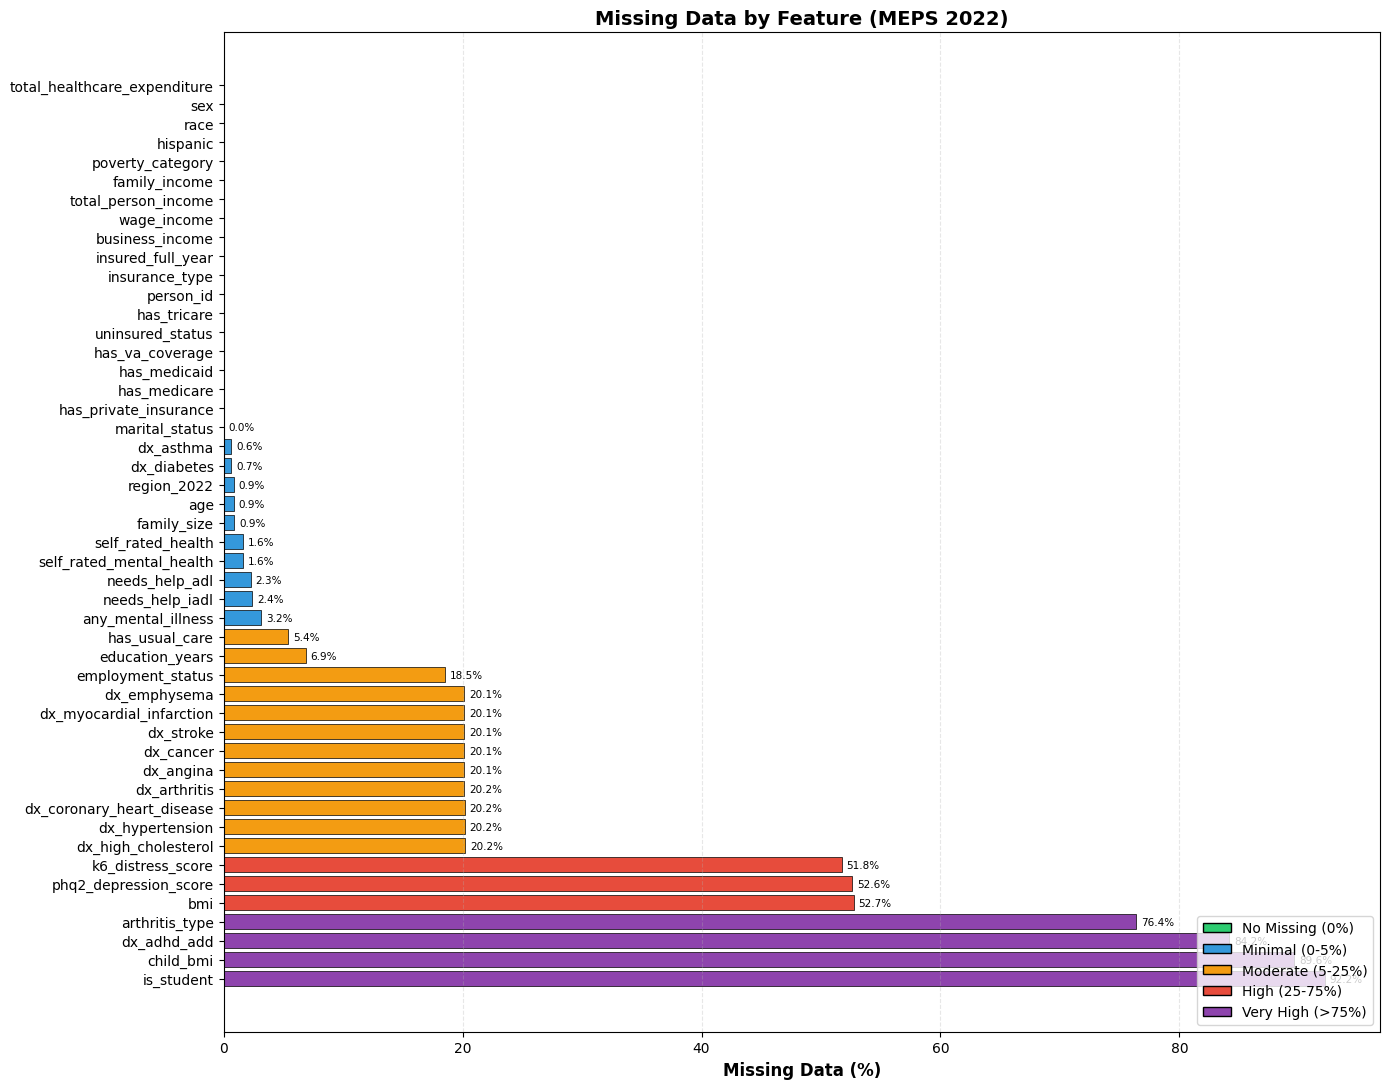

In [6]:
fig, ax = plt.subplots(figsize=(14, 11))

color_map = {}
for _, row in missing_data.iterrows():
    p = row['missing_pct']
    if p == 0:    color_map[row['feature']] = '#2ecc71'
    elif p <= 5:  color_map[row['feature']] = '#3498db'
    elif p <= 25: color_map[row['feature']] = '#f39c12'
    elif p <= 75: color_map[row['feature']] = '#e74c3c'
    else:         color_map[row['feature']] = '#8e44ad'

colors = [color_map[f] for f in missing_data['feature']]

bars = ax.barh(missing_data['feature'], missing_data['missing_pct'],
               color=colors, edgecolor='black', linewidth=0.5)

# Label every bar that has missing data
for bar, pct in zip(bars, missing_data['missing_pct']):
    if pct > 0:
        ax.text(pct + 0.4, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=7.5)

ax.set_xlabel('Missing Data (%)', fontsize=12, fontweight='bold')
ax.set_title('Missing Data by Feature (MEPS 2022)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')

legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label='No Missing (0%)'),
    Patch(facecolor='#3498db', edgecolor='black', label='Minimal (0-5%)'),
    Patch(facecolor='#f39c12', edgecolor='black', label='Moderate (5-25%)'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='High (25-75%)'),
    Patch(facecolor='#8e44ad', edgecolor='black', label='Very High (>75%)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## Visualization 2: Missing Data Heatmap

Sampled rows, columns sorted by missing % descending.  
Rows are also sorted so that the age-driven block patterns become visible.

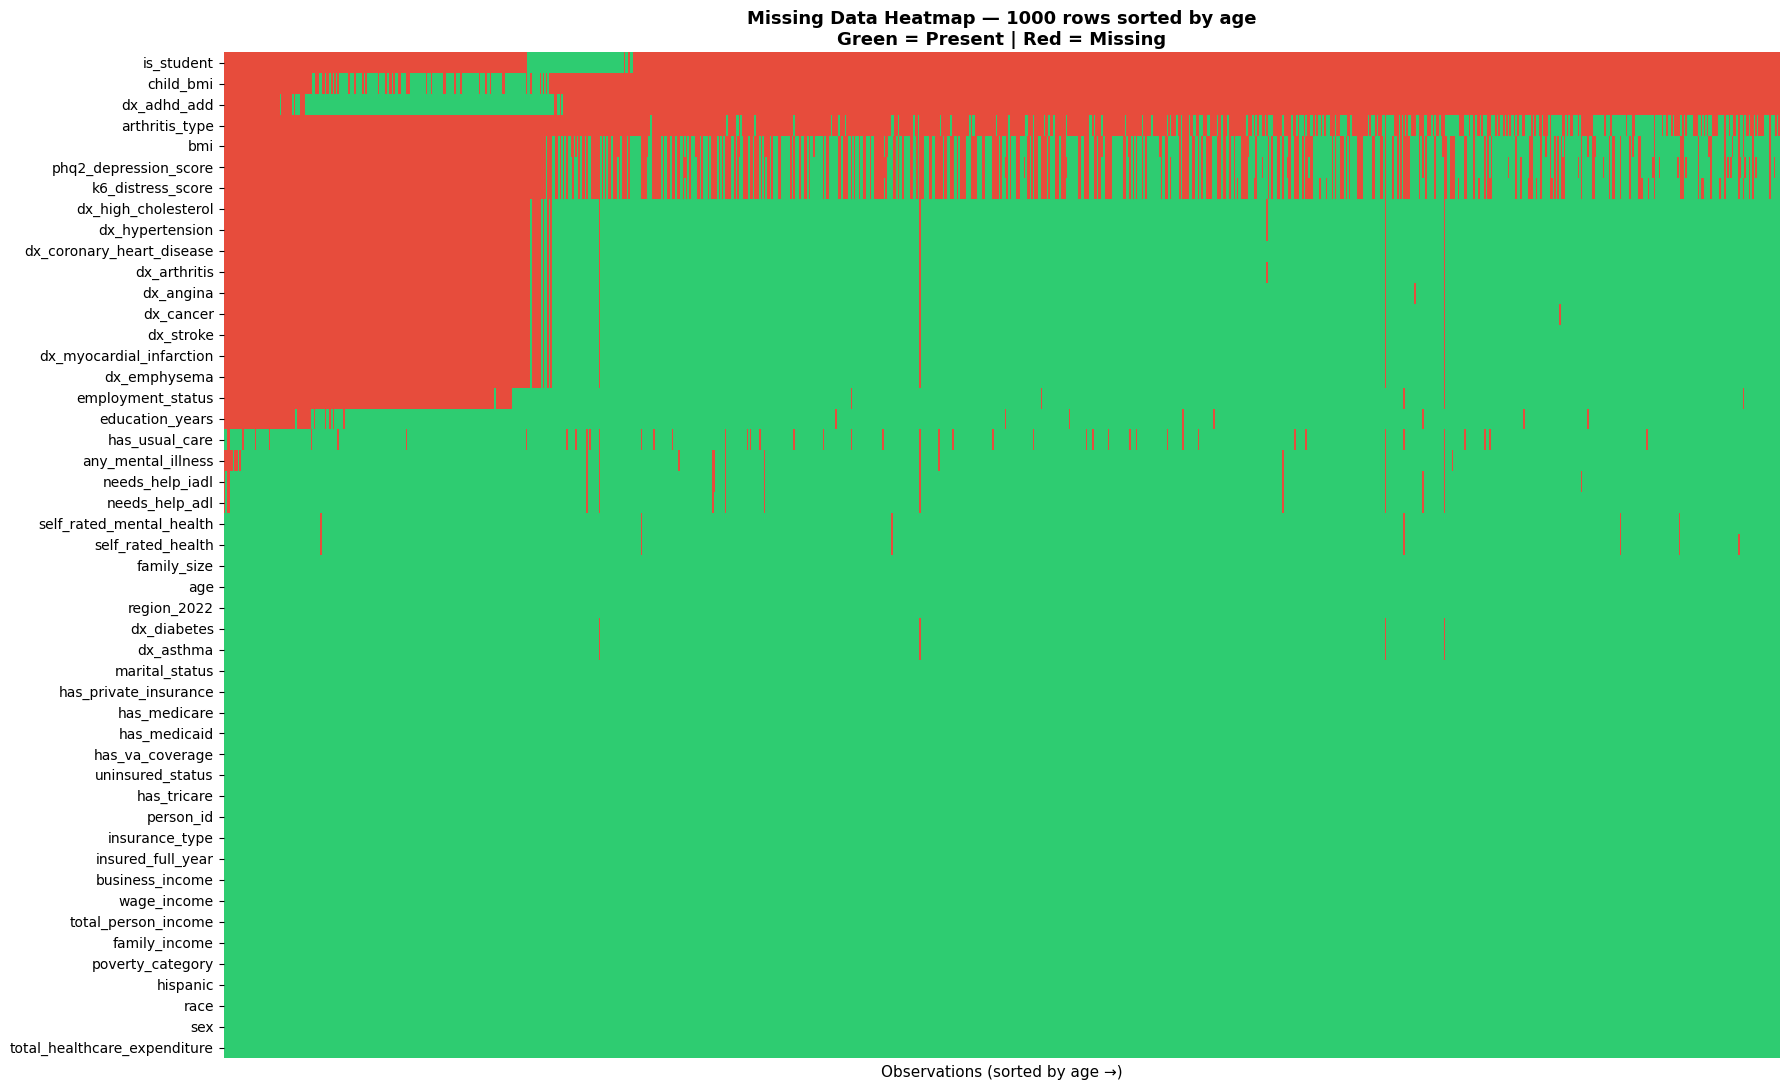

In [7]:
sample_size = 1000

# Sort sample by age so age-restricted blocks align visually
meps_sample = (
    meps_clean.dropna(subset=['age'])
    .sort_values('age')
    .sample(n=sample_size, random_state=42)
    .sort_values('age')  # re-sort after sample
)

cols_sorted = missing_data['feature'].tolist()
missing_matrix = meps_sample[cols_sorted].isnull().astype(int)

fig, ax = plt.subplots(figsize=(18, 11))
sns.heatmap(missing_matrix.T, cmap=['#2ecc71', '#e74c3c'], cbar=False,
            yticklabels=True, xticklabels=False, ax=ax, linewidths=0)

ax.set_title(f'Missing Data Heatmap — {sample_size} rows sorted by age\n'
             'Green = Present | Red = Missing',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Observations (sorted by age →)', fontsize=11)
plt.tight_layout()
plt.show()

## Age Distribution Context

Most missing data is **by design**: MEPS only asks certain questions for certain age groups.  
This cell establishes the age-group counts we'll reference throughout.

In [8]:
n = len(meps_clean)
age = meps_clean['age']

age_groups = [
    ('Under 5',                          age < 5),
    ('5-17  (children/teens)',           (age >= 5)  & (age < 18)),
    ('6-17  (child_bmi eligible)',       (age >= 6)  & (age < 18)),
    ('16+   (employment_status eligible)',(age >= 16)),
    ('17-23 (is_student eligible)',      (age >= 17) & (age <= 23)),
    ('18+   (adult chronic dx / bmi)',   age >= 18),
]

print(f"Total observations: {n:,}  (age missing: {age.isnull().sum()})\n")
for label, mask in age_groups:
    count = mask.sum()
    print(f"  {label:45} {count:6,}  ({count/n*100:5.1f}%)")

Total observations: 22,431  (age missing: 195)

  Under 5                                          960  (  4.3%)
  5-17  (children/teens)                         3,367  ( 15.0%)
  6-17  (child_bmi eligible)                     3,127  ( 13.9%)
  16+   (employment_status eligible)            18,447  ( 82.2%)
  17-23 (is_student eligible)                    1,565  (  7.0%)
  18+   (adult chronic dx / bmi)                17,909  ( 79.8%)


## Deep Dive — BMI

`bmi` = adult BMI (18+, top/bottom-coded at 50/10)  
`child_bmi` = child BMI (ages 6-17, same coding).  

These two are **mutually exclusive by age** — a natural candidate for a unified feature.

In [9]:
adults   = meps_clean['age'] >= 18
children = (meps_clean['age'] >= 6) & (meps_clean['age'] < 18)

n_adults   = adults.sum()
n_children = children.sum()

print("ADULT BMI (ages 18+)")
bmi_ok   = meps_clean.loc[adults, 'bmi'].notnull().sum()
bmi_miss = meps_clean.loc[adults, 'bmi'].isnull().sum()
print(f"  Eligible adults : {n_adults:,}")
print(f"  Present         : {bmi_ok:,}  ({bmi_ok/n_adults*100:.1f}%)")
print(f"  Missing         : {bmi_miss:,}  ({bmi_miss/n_adults*100:.1f}%)")
print(meps_clean.loc[adults & meps_clean['bmi'].notnull(), 'bmi'].describe())

print("\nCHILD BMI (ages 6-17)")
cbmi_ok   = meps_clean.loc[children, 'child_bmi'].notnull().sum()
cbmi_miss = meps_clean.loc[children, 'child_bmi'].isnull().sum()
print(f"  Eligible children: {n_children:,}")
print(f"  Present          : {cbmi_ok:,}  ({cbmi_ok/n_children*100:.1f}%)")
print(f"  Missing          : {cbmi_miss:,}  ({cbmi_miss/n_children*100:.1f}%)")
print(meps_clean.loc[children & meps_clean['child_bmi'].notnull(), 'child_bmi'].describe())

ADULT BMI (ages 18+)
  Eligible adults : 17,909
  Present         : 10,601  (59.2%)
  Missing         : 7,308  (40.8%)
count    10601.000000
mean        28.606254
std          6.646711
min         11.500000
25%         23.900000
50%         27.400000
75%         32.100000
max         50.000000
Name: bmi, dtype: float64

CHILD BMI (ages 6-17)
  Eligible children: 3,127
  Present          : 2,266  (72.5%)
  Missing          : 861  (27.5%)
count    2266.000000
mean       21.383230
std         6.019343
min        10.200000
25%        17.200000
50%        20.300000
75%        24.200000
max        50.000000
Name: child_bmi, dtype: float64


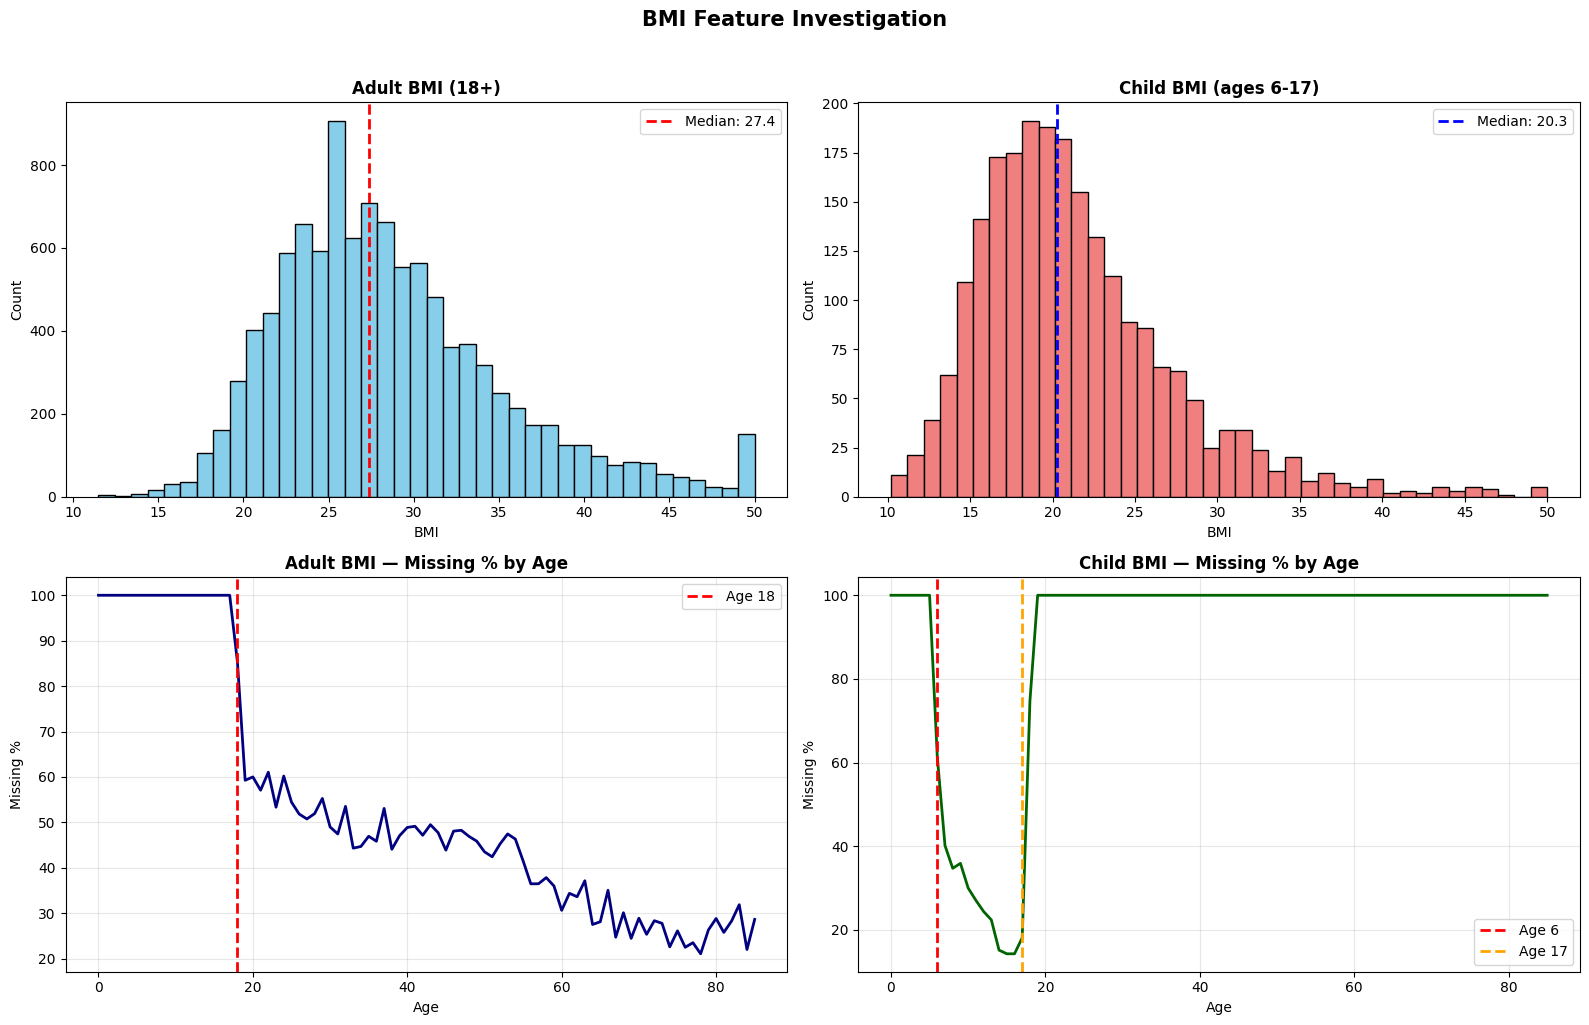

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- top-left: adult BMI histogram ---
adult_bmi = meps_clean.loc[adults, 'bmi'].dropna()
axes[0,0].hist(adult_bmi, bins=40, color='skyblue', edgecolor='black')
axes[0,0].axvline(adult_bmi.median(), color='red', ls='--', lw=2,
                  label=f'Median: {adult_bmi.median():.1f}')
axes[0,0].set_title('Adult BMI (18+)', fontweight='bold')
axes[0,0].set_xlabel('BMI')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# --- top-right: child BMI histogram ---
child_bmi = meps_clean.loc[children, 'child_bmi'].dropna()
axes[0,1].hist(child_bmi, bins=40, color='lightcoral', edgecolor='black')
axes[0,1].axvline(child_bmi.median(), color='blue', ls='--', lw=2,
                  label=f'Median: {child_bmi.median():.1f}')
axes[0,1].set_title('Child BMI (ages 6-17)', fontweight='bold')
axes[0,1].set_xlabel('BMI')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# --- bottom-left: adult BMI missing % by age ---
# Use len() for denominator so NaN rows are included in the total
age_bmi = meps_clean.groupby('age').agg(
    miss  =('bmi', lambda x: x.isnull().sum()),
    total =('bmi', lambda x: len(x))
)
age_bmi['pct'] = age_bmi['miss'] / age_bmi['total'] * 100

axes[1,0].plot(age_bmi.index, age_bmi['pct'], color='navy', lw=2)
axes[1,0].axvline(18, color='red', ls='--', lw=2, label='Age 18')
axes[1,0].set_title('Adult BMI — Missing % by Age', fontweight='bold')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Missing %')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# --- bottom-right: child BMI missing % by age ---
age_cbmi = meps_clean.groupby('age').agg(
    miss  =('child_bmi', lambda x: x.isnull().sum()),
    total =('child_bmi', lambda x: len(x))
)
age_cbmi['pct'] = age_cbmi['miss'] / age_cbmi['total'] * 100

axes[1,1].plot(age_cbmi.index, age_cbmi['pct'], color='darkgreen', lw=2)
axes[1,1].axvline(6,  color='red',    ls='--', lw=2, label='Age 6')
axes[1,1].axvline(17, color='orange', ls='--', lw=2, label='Age 17')
axes[1,1].set_title('Child BMI — Missing % by Age', fontweight='bold')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Missing %')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.suptitle('BMI Feature Investigation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Deep Dive — Student Status

`is_student` is only asked for **ages 17-23**.  
Everyone outside that range is coded `-1 INAPPLICABLE` → NaN after cleaning.

Key question: within 17-23, how complete is the data?

In [11]:
student_age = (meps_clean['age'] >= 17) & (meps_clean['age'] <= 23)
n_eligible  = student_age.sum()

s_present = meps_clean.loc[student_age, 'is_student'].notnull().sum()
s_missing = meps_clean.loc[student_age, 'is_student'].isnull().sum()

print(f"Eligible (ages 17-23): {n_eligible:,}")
print(f"  Present : {s_present:,}  ({s_present/n_eligible*100:.1f}%)")
print(f"  Missing : {s_missing:,}  ({s_missing/n_eligible*100:.1f}%)")

# Raw value counts within eligible range (includes refused/don't know)
print("\nRaw distribution (ages 17-23):")
raw_counts = meps.loc[student_age, 'is_student'].value_counts(dropna=False)
for val, cnt in raw_counts.items():
    print(f"    {str(val):35} {cnt:,}")

Eligible (ages 17-23): 1,565
  Present : 1,563  (99.9%)
  Missing : 2  (0.1%)

Raw distribution (ages 17-23):
    1 FULL-TIME STUDENT                 770
    3 NOT A STUDENT                     703
    2 PART-TIME STUDENT                 90
    -7 REFUSED                          2
    -8 DON'T KNOW                       0
    -1 INAPPLICABLE                     0


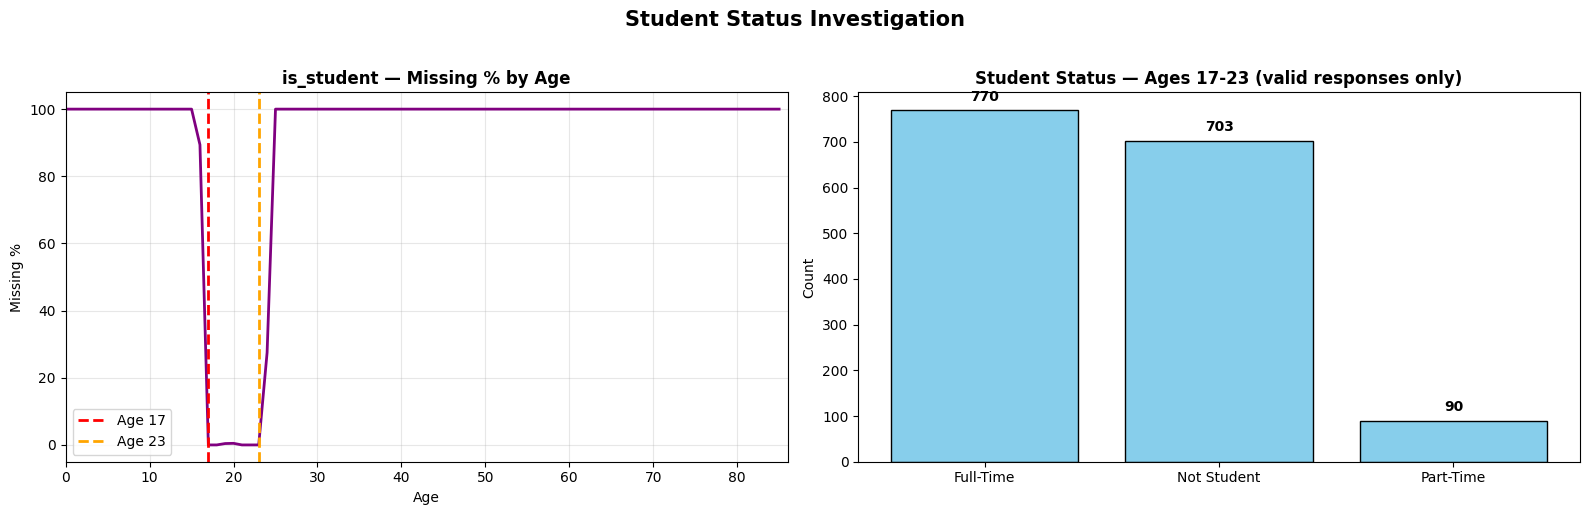

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- left: missing % by age across full range ---
age_stu = meps_clean.groupby('age').agg(
    miss  =('is_student', lambda x: x.isnull().sum()),
    total =('is_student', lambda x: len(x))
)
age_stu['pct'] = age_stu['miss'] / age_stu['total'] * 100

axes[0].plot(age_stu.index, age_stu['pct'], color='purple', lw=2)
axes[0].axvline(17, color='red',    ls='--', lw=2, label='Age 17')
axes[0].axvline(23, color='orange', ls='--', lw=2, label='Age 23')
axes[0].set_title('is_student — Missing % by Age', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Missing %')
axes[0].set_xlim(0, 86)
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- right: distribution of valid values within 17-23 ---
# Use cleaned data; drop NaN so only real responses show
valid_counts = meps_clean.loc[student_age, 'is_student'].value_counts(dropna=True)

label_map = {
    '1 FULL-TIME STUDENT': 'Full-Time',
    '2 PART-TIME STUDENT': 'Part-Time',
    '3 NOT A STUDENT':     'Not Student',
}
labels = [label_map.get(str(v), str(v)) for v in valid_counts.index]

axes[1].bar(labels, valid_counts.values, color='skyblue', edgecolor='black')
axes[1].set_title('Student Status — Ages 17-23 (valid responses only)', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(valid_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle('Student Status Investigation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Deep Dive — Mental Health Scores (SAQ)

`k6_distress_score` (0-24) and `phq2_depression_score` (0-6) are **Self-Administered Questionnaire** variables:
- Only administered to adults 18+
- Not every eligible adult completes the SAQ → additional missingness beyond the age cut

Key question: among adults, what fraction actually has a score?

In [13]:
for name, col, scale in [
    ('K6 Distress',  'k6_distress_score',     '0-24'),
    ('PHQ-2 Depression', 'phq2_depression_score', '0-6'),
]:
    present_all   = meps_clean[col].notnull().sum()
    present_adult = meps_clean.loc[adults, col].notnull().sum()
    missing_adult = meps_clean.loc[adults, col].isnull().sum()

    print(f"\n{name} ({scale})")
    print(f"  Present overall      : {present_all:,}  ({present_all/len(meps_clean)*100:.1f}%)")
    print(f"  Present among 18+    : {present_adult:,}  ({present_adult/n_adults*100:.1f}% of adults)")
    print(f"  Missing among 18+    : {missing_adult:,}  ({missing_adult/n_adults*100:.1f}% of adults)")
    print(meps_clean[col].describe())


K6 Distress (0-24)
  Present overall      : 10,823  (48.3%)
  Present among 18+    : 10,823  (60.4% of adults)
  Missing among 18+    : 7,086  (39.6% of adults)
count    10823.000000
mean         3.158366
std          4.109216
min          0.000000
25%          0.000000
50%          2.000000
75%          5.000000
max         24.000000
Name: k6_distress_score, dtype: float64

PHQ-2 Depression (0-6)
  Present overall      : 10,632  (47.4%)
  Present among 18+    : 10,632  (59.4% of adults)
  Missing among 18+    : 7,277  (40.6% of adults)
count    10632.000000
mean         0.662340
std          1.249581
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          6.000000
Name: phq2_depression_score, dtype: float64


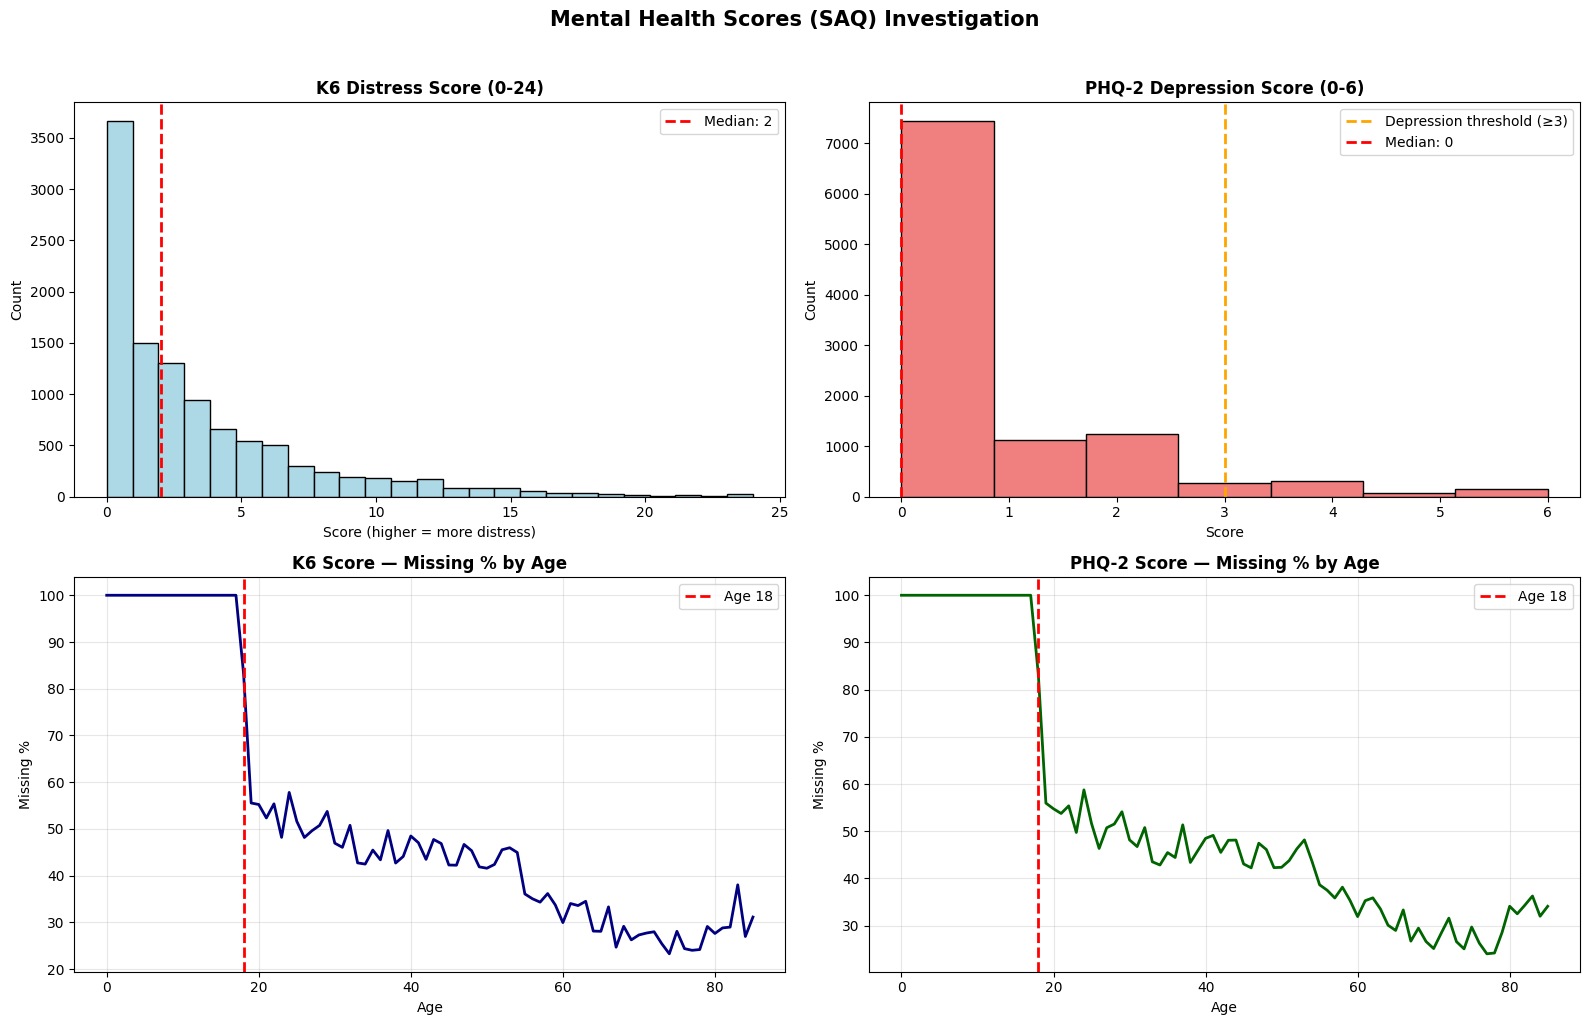

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- top-left: K6 distribution ---
k6 = meps_clean['k6_distress_score'].dropna()
axes[0,0].hist(k6, bins=25, color='lightblue', edgecolor='black')
axes[0,0].axvline(k6.median(), color='red', ls='--', lw=2, label=f'Median: {k6.median():.0f}')
axes[0,0].set_title('K6 Distress Score (0-24)', fontweight='bold')
axes[0,0].set_xlabel('Score (higher = more distress)')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# --- top-right: PHQ-2 distribution ---
phq = meps_clean['phq2_depression_score'].dropna()
axes[0,1].hist(phq, bins=7, color='lightcoral', edgecolor='black')
axes[0,1].axvline(3, color='orange', ls='--', lw=2, label='Depression threshold (≥3)')
axes[0,1].axvline(phq.median(), color='red', ls='--', lw=2, label=f'Median: {phq.median():.0f}')
axes[0,1].set_title('PHQ-2 Depression Score (0-6)', fontweight='bold')
axes[0,1].set_xlabel('Score')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# --- bottom-left: K6 missing % by age ---
age_k6 = meps_clean.groupby('age').agg(
    miss  =('k6_distress_score', lambda x: x.isnull().sum()),
    total =('k6_distress_score', lambda x: len(x))
)
age_k6['pct'] = age_k6['miss'] / age_k6['total'] * 100

axes[1,0].plot(age_k6.index, age_k6['pct'], color='navy', lw=2)
axes[1,0].axvline(18, color='red', ls='--', lw=2, label='Age 18')
axes[1,0].set_title('K6 Score — Missing % by Age', fontweight='bold')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Missing %')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# --- bottom-right: PHQ-2 missing % by age ---
age_phq = meps_clean.groupby('age').agg(
    miss  =('phq2_depression_score', lambda x: x.isnull().sum()),
    total =('phq2_depression_score', lambda x: len(x))
)
age_phq['pct'] = age_phq['miss'] / age_phq['total'] * 100

axes[1,1].plot(age_phq.index, age_phq['pct'], color='darkgreen', lw=2)
axes[1,1].axvline(18, color='red', ls='--', lw=2, label='Age 18')
axes[1,1].set_title('PHQ-2 Score — Missing % by Age', fontweight='bold')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Missing %')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.suptitle('Mental Health Scores (SAQ) Investigation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Summary & Cleaning Strategy

### What drives the missing data?

Almost all missing data is **MEPS survey design**, not data-quality issues:

| Feature | Why it's missing | Missing ~% |
|---|---|---|
| `child_bmi` | Only ages 6-17 | ~86% |
| `is_student` | Only ages 17-23 | ~93% |
| `dx_adhd_add` | Only ages 5-17 | ~85% |
| `k6_distress_score` | SAQ adults 18+ only | ~50% |
| `phq2_depression_score` | SAQ adults 18+ only | ~50% |
| `bmi` | Adults 18+ only | ~20% |
| Chronic conditions | Adults 18+ only | ~19% |
| `employment_status` | Ages 16+ only | ~7% |
| `education_years` | Ages 5+ only | ~4% |

### Recommended approach for the SQLite app

1. **Unified BMI** — combine `bmi` and `child_bmi` into one column (`bmi` filled from `child_bmi` where NaN). Covers all ages 6+.
2. **Keep `is_student`** — encode outside 17-23 as a dedicated "N/A" category; the model learns that age already captures this.
3. **K6 / PHQ-2** — for the prediction app these are user inputs only when age ≥ 18; default to 0 (no distress) otherwise.
4. **Chronic conditions** — same age-gate logic: default to 0 (no diagnosis) for ages < 18.
5. **`dx_adhd_add`** — keep; encode outside 5-17 as 0.
6. **Features with 0% missing** (demographics, insurance indicators, target) — no action needed.

### Do NOT drop yet
No features are dropped in this notebook — that decision happens in the model-prep notebook after encoding.

In [15]:
total_cells  = len(meps_clean) * len(meps_clean.columns)
total_nan    = meps_clean.isnull().sum().sum()

print("="*70)
print("MISSING DATA SUMMARY".center(70))
print("="*70)
print(f"  Rows × Columns : {len(meps_clean):,} × {len(meps_clean.columns)}")
print(f"  Total NaN cells: {total_nan:,}  ({total_nan/total_cells*100:.2f}% of matrix)")
print(f"  No missing      : {len(no_missing):>2} features")
print(f"  Minimal  <5%    : {len(minimal_missing):>2} features")
print(f"  Moderate 5-25%  : {len(moderate_missing):>2} features")
print(f"  High     25-75% : {len(high_missing):>2} features")
print(f"  Very high >75%  : {len(very_high_missing):>2} features")
print("="*70)

                         MISSING DATA SUMMARY                         
  Rows × Columns : 22,431 × 48
  Total NaN cells: 163,005  (15.14% of matrix)
  No missing      : 18 features
  Minimal  <5%    : 11 features
  Moderate 5-25%  : 12 features
  High     25-75% :  3 features
  Very high >75%  :  4 features
